# Modelagem de Regressão para Predição de Gorjetas



### Uma jornada analítica na busca pelo modelo estatístico mais eficiente

In [97]:
# Manipulação  e visualização de dados
import numpy as np
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Regressão
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Parametrização
%matplotlib inline

In [98]:
# Base de dados
tips = sns.load_dataset("tips")

# Coluna do percentual de gorjeta
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])

# Coluna do valor líquido da conta
tips['net_bill'] = tips['total_bill'] - tips['tip']

# Visualização das primeiras linhas da base de dados
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,net_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.063204,15.98
1,10.34,1.66,Male,No,Sun,Dinner,3,0.191244,8.68
2,21.01,3.50,Male,No,Sun,Dinner,3,0.199886,17.51
3,23.68,3.31,Male,No,Sun,Dinner,2,0.162494,20.37
4,24.59,3.61,Female,No,Sun,Dinner,4,0.172069,20.98


In [99]:
# Matriz de design e matriz y
y, X = patsy.dmatrices('tip ~ sex + smoker + time + net_bill', tips)

# Modelo de regressão
modelo_linear = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           2.64e-20
Time:                        12:15:06   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             760.3
Df Residuals:                     239   BIC:                             777.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1999      0.242      4.952      0.000       0.723       1.677
sex[T.Female]     -0.0034      0.156     -0.022      0.982      -0.311       0.305
smoker[T.No]       0.1405      0.151      0.932      0.352      -0.156       0.437
time[T.Dinner]     0.0584      0.168      0.347      0.729      -0.273       0.390
net_bill           0.0995      0.009     10.662      0.000       0.081       0.118
==============================================================================
Omnibus:                       36.537   Durbin-Watson:                   2.121
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.875
Skew:                           0.800   Prob(JB):                     4.96e-15
Kurtosis:                       4.980   Cond. No.                         71.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [100]:
# Matriz de design refinada ao remover variáveis insignificantes
y, X = patsy.dmatrices('tip ~ net_bill', tips)

# Modelo de regressão
modelo_linear = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_linear.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     120.6
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           5.02e-23
Time:                        12:15:06   Log-Likelihood:                -375.63
No. Observations:                 244   AIC:                             755.3
Df Residuals:                     242   BIC:                             762.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.3307      0.168      7.907      0.000       0.999       1.662
net_bill       0.0993      0.009     10.980      0.000       0.082       0.117
==============================================================================
Omnibus:                       33.873   Durbin-Watson:                   2.123
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.942
Skew:                           0.754   Prob(JB):                     9.63e-14
Kurtosis:                       4.903   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

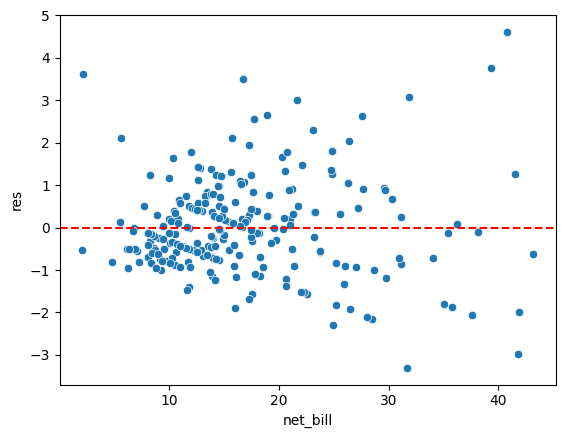

In [ ]:
# Análise de resíduos 
tips['res'] = modelo_linear.resid

# Visualização de resíduos
sns.scatterplot(x='net_bill', y='res', data=tips)
plt.axhline(y=0, color='r', linestyle='--');

In [102]:
# Matriz de design com o log
y, X = patsy.dmatrices('tip ~ np.log(net_bill)', tips)

# Modelo de regressão
modelo_log = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     101.0
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.40e-20
Time:                        12:15:06   Log-Likelihood:                -382.40
No. Observations:                 244   AIC:                             768.8
Df Residuals:                     242   BIC:                             775.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.2575      0.430     -2.924      0.004      -2.104      -0.410
np.log(net_bill)     1.5695      0.156     10.049      0.000       1.262       1.877
==============================================================================
Omnibus:                       73.945   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              221.148
Skew:                           1.303   Prob(JB):                     9.51e-49
Kurtosis:                       6.868   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

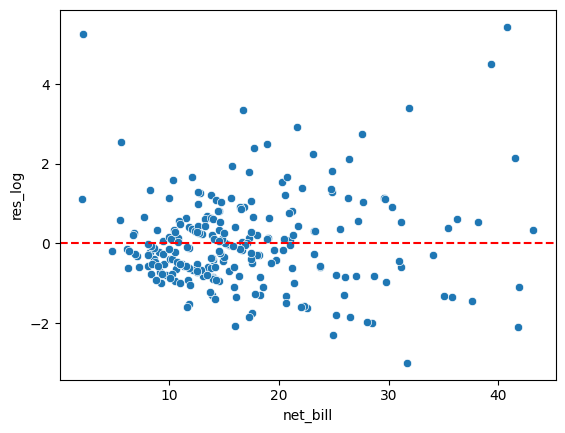

In [ ]:
# Análise de resíduos 
tips['res_log'] = modelo_log.resid

# Visualização de resíduos
sns.scatterplot(x='net_bill', y='res_log', data=tips)
plt.axhline(y=0, color='r', linestyle='--');

In [104]:
# Matriz de design com o polinômio de segundo grau
y, X = patsy.dmatrices('tip ~ np.power(net_bill,2)', tips)

# Modelo de regressão
modelo_quadratico = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_quadratico.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     104.1
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           1.47e-20
Time:                        12:15:06   Log-Likelihood:                -381.31
No. Observations:                 244   AIC:                             766.6
Df Residuals:                     242   BIC:                             773.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.2566      0.104     21.720      0.000       2.052       2.461
np.power(net_bill, 2)     0.0021      0.000     10.202      0.000       0.002       0.003
==============================================================================
Omnibus:                       22.756   Durbin-Watson:                   2.184
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.466
Skew:                           0.620   Prob(JB):                     1.47e-07
Kurtosis:                       4.248   Cond. No.                         692.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

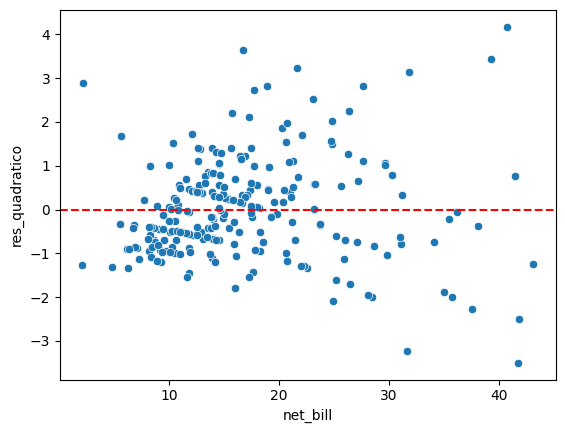

In [ ]:
# Análise de resíduos 
tips['res_quadratico'] = modelo_quadratico.resid

# Visualização de resíduos
sns.scatterplot(x='net_bill', y='res_quadratico', data=tips)
plt.axhline(y=0, color='r', linestyle='--');

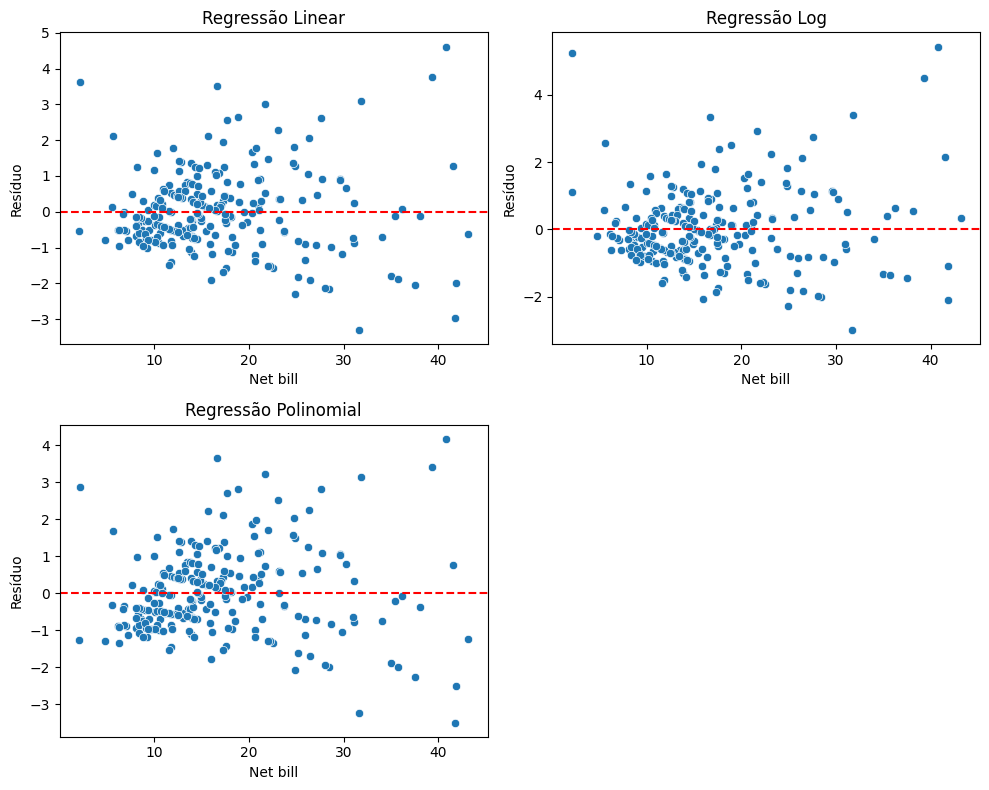

                                                     Avaliação de regressões🧠                                                     

Regressão linear (tip ~ net_bill)
R² = 0.333 ✅ (maior)
AIC = 755.3 ✅ (menor)
      
Regressão log (tip ~ log(net_bill))
R² = 0.294 ❌ 
AIC = 768.8 ❌ 
      
Regressão polinomial (tip ~ net_bill²)
R² = 0.301 ❌
AIC = 766.6 ❌

A regressão linear se mostra como a melhor escolha entre os avaliados.
No entanto, seu poder explicativo ainda é moderado, indicando que o modelo
pode ser aprimorado com a inclusão de novas variáveis estatisticamente 
significativas, a fim de capturar melhor a variabilidade da variável resposta.



In [106]:
# Análise de testes
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Gráfico 1: regressão linear
sns.scatterplot(x='net_bill', y='res', data=tips, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title("Regressão Linear")
axes[0,0].set_xlabel("Net bill")
axes[0,0].set_ylabel("Resíduo")

# Gráfico 2: regressão log
sns.scatterplot(x='net_bill', y='res_log', data=tips, ax=axes[0,1])
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_title("Regressão Log")
axes[0,1].set_xlabel("Net bill")
axes[0,1].set_ylabel("Resíduo")

# Gráfico 3: regressão polinomial
sns.scatterplot(x='net_bill', y='res_quadratico', data=tips, ax=axes[1,0])
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_title("Regressão Polinomial")
axes[1,0].set_xlabel("Net bill")
axes[1,0].set_ylabel("Resíduo")

# Remove o gráfico vazio (posição [1,1])
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()


print("Avaliação de regressões🧠".center(130))
print("="*130)

print("""
Regressão linear (tip ~ net_bill)
R² = 0.333 ✅ (maior)
AIC = 755.3 ✅ (menor)
      
Regressão log (tip ~ log(net_bill))
R² = 0.294 ❌ 
AIC = 768.8 ❌ 
      
Regressão polinomial (tip ~ net_bill²)
R² = 0.301 ❌
AIC = 766.6 ❌

A regressão linear se mostra como a melhor escolha entre os avaliados.
No entanto, seu poder explicativo ainda é moderado, indicando que o modelo
pode ser aprimorado com a inclusão de novas variáveis estatisticamente 
significativas, a fim de capturar melhor a variabilidade da variável resposta.
""")

In [107]:
# Matriz de design refinada ao adicionar variáveis significantes
y, X = patsy.dmatrices('tip ~ net_bill  + size', tips)

# Modelo de regressão
modelo_linear = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     70.44
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           8.15e-25
Time:                        12:15:07   Log-Likelihood:                -368.79
No. Observations:                 244   AIC:                             743.6
Df Residuals:                     241   BIC:                             754.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8479      0.209      4.057      0.000       0.436       1.260
net_bill       0.0760      0.011      7.032      0.000       0.055       0.097
size           0.3402      0.091      3.727      0.000       0.160       0.520
==============================================================================
Omnibus:                       43.472   Durbin-Watson:                   2.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.448
Skew:                           0.887   Prob(JB):                     6.22e-20
Kurtosis:                       5.356   Cond. No.                         57.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

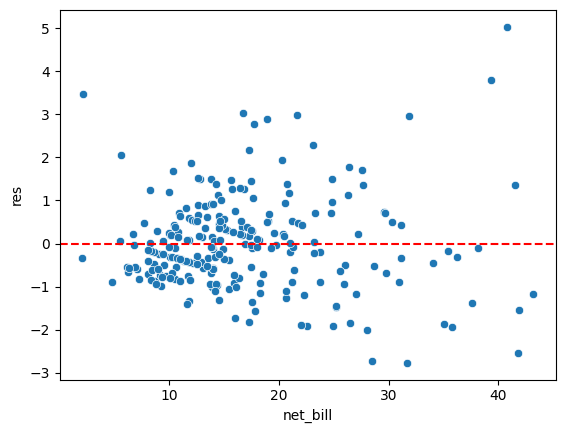

                                                  Conclusão🧠                                                  
Regressão Linear
 R²= 0.37
 AIC= 743.59

A inclusão de variáveis relevantes melhorou o poder explicativo e a qualidade do modelo.
A regressão linear com múltiplas variáveis se mostra mais apropriada do que versões simplificadas anteriores.
O próximo desafio é ajustar a heterocedasticidade.



In [ ]:
# Análise de resíduos 
tips['res'] = modelo_linear.resid

# Visualização de resíduos
sns.scatterplot(x='net_bill', y='res', data=tips)
plt.axhline(y=0, color='r', linestyle='--');
plt.show()

print("Conclusão🧠".center(110))
print("="*110)

template = "Regressão {a}\n R²= {r2:.2f}\n AIC= {AIC:.2f}"

print(template.format(a="Linear", r2=modelo_linear.rsquared, AIC=modelo_linear.aic))

print("""
A inclusão de variáveis relevantes melhorou o poder explicativo e a qualidade do modelo.
A regressão linear com múltiplas variáveis se mostra mais apropriada do que versões simplificadas anteriores.
O próximo desafio é ajustar a heterocedasticidade.
""")

In [109]:
# Matriz de design log-log
y, X = patsy.dmatrices('np.log(tip) ~ np.log(net_bill)  + size', tips)

# Modelo de regressão
modelo_log_log = sm.OLS(y,X).fit()

# Summary do modelo de regressão
modelo_log_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            np.log(tip)   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     67.09
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           6.85e-24
Time:                        12:15:07   Log-Likelihood:                -89.261
No. Observations:                 244   AIC:                             184.5
Df Residuals:                     241   BIC:                             195.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3421      0.130     -2.625      0.009      -0.599      -0.085
np.log(net_bill)     0.3925      0.057      6.878      0.000       0.280       0.505
size                 0.1090      0.029      3.799      0.000       0.053       0.166
==============================================================================
Omnibus:                        7.061   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.029   Jarque-Bera (JB):               11.015
Skew:                           0.106   Prob(JB):                      0.00406
Kurtosis:                       4.019   Cond. No.                         24.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

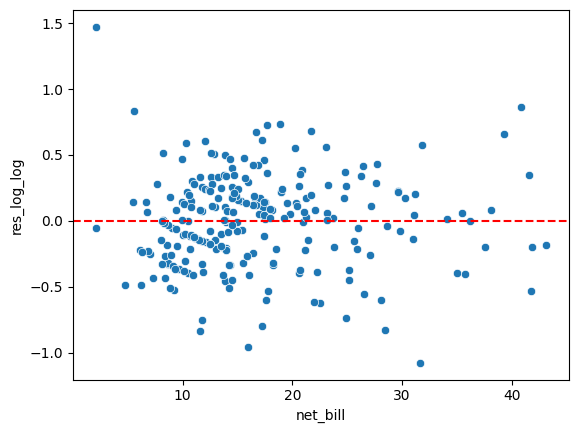

In [ ]:
# Análise de resíduos 
tips['res_log_log'] = modelo_log_log.resid

# Visualização de resíduos
sns.scatterplot(x='net_bill', y='res_log_log', data=tips)
plt.axhline(y=0, color='r', linestyle='--');

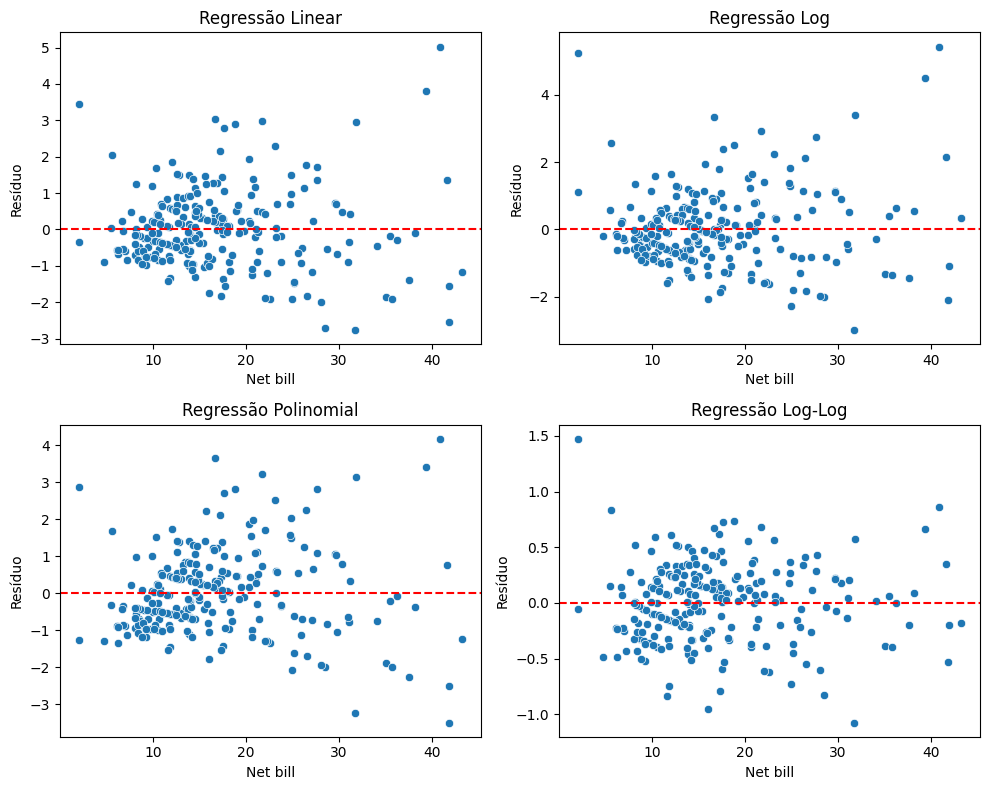

                                                    Resultado das regressões                                                      
Regressão Linear
 R²= 0.37
 AIC= 743.59

Regressão Log
 R²= 0.29
 AIC= 768.80

Regressão Polinomial
 R²= 0.30
 AIC= 766.62

Regressão Log-Log
 R²= 0.36
 AIC= 184.52

O modelo log-log é considerado mais adequado do ponto de vista estatístico.✅


In [ ]:
# Parametrização da visualização
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Gráfico 1: regressão linear
sns.scatterplot(x='net_bill', y='res', data=tips, ax=axes[0,0])
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title("Regressão Linear")
axes[0,0].set_xlabel("Net bill")
axes[0,0].set_ylabel("Resíduo")

# Gráfico 2: regressão log
sns.scatterplot(x='net_bill', y='res_log', data=tips, ax=axes[0,1])
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_title("Regressão Log")
axes[0,1].set_xlabel("Net bill")
axes[0,1].set_ylabel("Resíduo")

# Gráfico 3: regressão polinomial
sns.scatterplot(x='net_bill', y='res_quadratico', data=tips, ax=axes[1,0])
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_title("Regressão Polinomial")
axes[1,0].set_xlabel("Net bill")
axes[1,0].set_ylabel("Resíduo")

# Gráfico 4: regressão log-log
sns.scatterplot(x='net_bill', y='res_log_log', data=tips, ax=axes[1,1])
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_title("Regressão Log-Log")
axes[1,1].set_xlabel("Net bill")
axes[1,1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()

print("Resultado das regressões ".center(130))
print("="*130)

template = "Regressão {a}\n R²= {r2:.2f}\n AIC= {AIC:.2f}\n" 

print(template.format(a="Linear", r2=modelo_linear.rsquared, AIC=modelo_linear.aic))

print(template.format(a="Log", r2=modelo_log.rsquared, AIC=modelo_log.aic))

print(template.format(a="Polinomial", r2=modelo_quadratico.rsquared, AIC=modelo_quadratico.aic))

print(template.format(a="Log-Log", r2=modelo_log_log.rsquared, AIC=modelo_log_log .aic))

print("""O modelo log-log é considerado mais adequado do ponto de vista estatístico.✅""")